# Wasserstein Generative Adversial Networks (GAN) for generation of MNIST digits : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

This practical session is based on the [DCGAN Pytorch tutorial](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html). 
Recquire a CPU

## Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torchvision.utils import make_grid
import torch.utils.data as data

import matplotlib.pyplot as plt
import os
import numpy as np
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device is", device)
# !nvidia-smi

# Displaying function
def imshow(img,size=None):
    img = img*0.5 + 0.5     # unnormalize
    if size is not None:
        img = transforms.Resize(size=size, interpolation=transforms.InterpolationMode.NEAREST, antialias=True)(img)
    pil_img = transforms.functional.to_pil_image(img)
    display(pil_img)
    # print("Image size (h x w): ",  pil_img.height, "x", pil_img.width)
    return None

Device is cpu


## Download MNIST dataset

Note that we normalize the images between -1 and 1 because during sampling, we have to limit the input space and scaling between -1 and 1 makes it easier to implement it. We discard the last batch so that all batches have the same size.

In [2]:
batch_size=128
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


We draw a batch of real images with the train_loader and display them. Use `next` and `iter` to get a batch from `train_loader`.

torch.Size([128, 1, 28, 28])


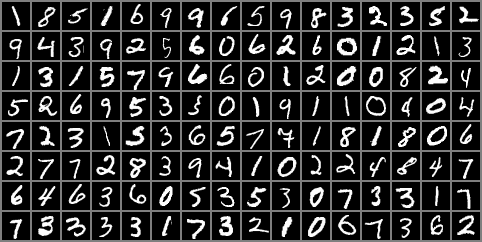

In [4]:
real,_ = next(iter(train_loader))
print(real.shape)

pil_img = imshow(make_grid(real.to('cpu'),nrow=16))

## Generator and Discriminator Models

The architecture of DCGAN is described in the [(Radford et al., 2016)](https://arxiv.org/pdf/1511.06434.pdf)

We examine the architecture of the following generator and discriminator.

In [5]:
# Size  of generator input
nz = 100

# Size of feature maps in generator and discriminator
ngf, ndf = 64, 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(in_channels = nz, out_channels = ngf * 8, kernel_size = 4, stride = 1, padding = 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(in_channels = ngf * 8, out_channels = ngf * 4, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(in_channels = ngf * 4, out_channels = ngf * 2, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(in_channels = ngf * 2, out_channels = ngf, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(in_channels = ngf, out_channels = 1, kernel_size=1, stride=1, padding=2, bias=False),
            nn.Tanh()
            # output size. 1 x 28 x 28
        )

    def forward(self, input):
        return self.main(input)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input is 1 x 28 x 28
            nn.Conv2d(in_channels = 1, out_channels = ndf, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 14 x 14
            nn.Conv2d(in_channels = ndf, out_channels= ndf * 2, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 8 x 8
            nn.Conv2d(in_channels = ndf * 2, out_channels = ndf * 4, kernel_size = 4, stride = 2, padding = 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 4 x 4
            nn.Conv2d(in_channels = ndf * 4, out_channels = 1, kernel_size = 4, stride = 2, padding = 1, bias=False)
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

## Weight initialization

The DCGAN [paper](https://arxiv.org/pdf/1511.06434.pdf) mentions that all model weights shall be randomly initialized from a Normal distribution with $\mu=0$ and $\sigma=0.02$. We implement `weights_init` function to reinitialize the weights.

In [6]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Create the generator and discriminator
G = Generator().to(device)
D = Discriminator().to(device)

# Apply the weights_init function to randomly initialize all weights to mean=0, stdev=0.02.
G.apply(weights_init);
D.apply(weights_init);

## Print Architectures of Generator and Discriminator

In [9]:
import torchsummary

# Create some generator and discriminator
G = Generator().to(device)
D = Discriminator().to(device)

torchsummary.summary(G, input_size=(nz,1,1))
torchsummary.summary(D, input_size=(1,28,28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         819,200
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
              ReLU-3            [-1, 512, 4, 4]               0
   ConvTranspose2d-4            [-1, 256, 8, 8]       2,097,152
       BatchNorm2d-5            [-1, 256, 8, 8]             512
              ReLU-6            [-1, 256, 8, 8]               0
   ConvTranspose2d-7          [-1, 128, 16, 16]         524,288
       BatchNorm2d-8          [-1, 128, 16, 16]             256
              ReLU-9          [-1, 128, 16, 16]               0
  ConvTranspose2d-10           [-1, 64, 32, 32]         131,072
      BatchNorm2d-11           [-1, 64, 32, 32]             128
             ReLU-12           [-1, 64, 32, 32]               0
  ConvTranspose2d-13            [-1, 1, 28, 28]              64
             Tanh-14            [-1, 1,

## Display Samples of the Generator

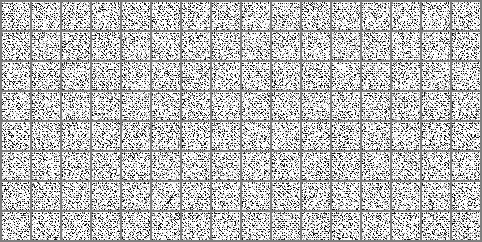

In [ ]:
# function to display samples of the generator
def show(G,z=None,batch_size=128,nz=100):
  # provide random latent code as option to see evolution
  with torch.no_grad():
    if z==None:
      z = torch.randn(batch_size,nz,1,1).to(device)
    genimages = G(z)
    pil_img = imshow(utils.make_grid(genimages.to('cpu'),nrow=16))
    return(pil_img)

show(G)

<br/><br/><br/><br/><br/>

# Part 1: DCGAN Training with WGAN-GP loss

<br/><br/>


We understand the following function that computes the mean variation and the gradient penalty of D:
$$ \mathsf{MV}(D) = \mathbb{E}\Big[ \| \nabla D(A)\| \Big] $$
$$ \mathsf{GP}(D) = \mathbb{E}\Big[ ( \| \nabla D(A)\| - 1 )^2 \Big] $$
where $A$ is drawn uniformly on a random segment $[X,Y]$.

In [11]:
def meanvariation(D,x,y):
    # Calculate interpolation between points in batches x and y (of same size b)
    b = x.shape[0]
    if y.shape[0]!=b:
        print('wrong size')
    alpha = torch.rand((b,1,1,1),device=device)
    a = alpha * y + (1 - alpha) * x
    a.requires_grad_()

    # Calculate probability of interpolated examples
    Da = D(a).view(-1)

    # Calculate gradients of probabilities with respect to examples
    gradout = torch.ones(Da.size()).to(device)
    gradients = torch.autograd.grad(outputs=Da, inputs=a, grad_outputs=gradout,
       create_graph=True, retain_graph=True)[0]

    # Derivatives of the gradient close to 0 can cause problems because of
    # the square root, so manually calculate norm and add epsilon
    gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=[1,2,3]))

    # Return gradient penalty
    return torch.mean(gradients_norm)

def gradient_penalty(D,x,y):
    # Calculate interpolation
    b = x.shape[0]
    if y.shape[0]!=b:
        print('wrong size')
    alpha = torch.rand((b,1,1,1),device=device)
    interp = (alpha * y + (1 - alpha) * x)
    interp.requires_grad_()

    # Calculate probability of interpolated examples
    Di = D(interp).view(-1)

    # Calculate gradients of probabilities with respect to examples
    gradout = torch.ones(Di.size()).to(device)
    gradients = torch.autograd.grad(outputs=Di, inputs=interp, grad_outputs=gradout,
       create_graph=True, retain_graph=True)[0]

    # Derivatives of the gradient close to 0 can cause problems because of
    # the square root, so manually calculate norm and add epsilon
    gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=[1,2,3]) + 1e-12)

    # Return gradient penalty
    return ((gradients_norm - 1) ** 2).mean()

y = next(iter(train_loader))[0].to(device)
x = G(torch.randn(batch_size, nz, 1, 1, device=device)).detach()

print(meanvariation(D,x,y))
print(gradient_penalty(D,x,y))

tensor(0.5957, grad_fn=<MeanBackward0>)
tensor(0.1803, grad_fn=<MeanBackward0>)


Implement WGAN-GP training for MNIST by completing the code in the following cell.
We recall the pseudo-code:

> For each batch of images $x_{\text{real}}$:
>
> **1) Train discriminator:**
> > Generate $z$ a tensor of size $b\times nz\times 1\times 1$ of idd Gaussian variables  
> > Generate  $x_{\text{fake}} = \mathtt{G}(z)$ a set $b$ fake images  
> > Compute the discriminator loss to maximize <br/>
> > Compute the gradient and do an optimizer step for the disciminator parameters  
>
> **2) Train the generator:**
> > Generate $z$ a new tensor of size $b\times nz\times 1\times 1$ of idd Gaussian variables  
> > Compute the generator loss to minimize <br/>
> > Compute the gradient and do an optimizer step for the generator parameters

C:\Users\alexa\AppData\Local\Temp\ipykernel_19760\4066297214.py:56: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('[%d/%d][%d/%d][%.4f s]\tLoss_D: %.4f\tLoss_G: %.4f\tLip(D): %.4f'


[1/5][0/468][9.2110 s]	Loss_D: 0.0877	Loss_G: 1.4278	Lip(D): 1.7186


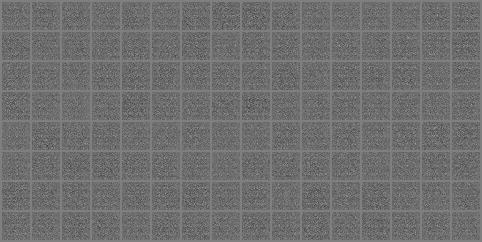

[1/5][100/468][267.2581 s]	Loss_D: -9.9557	Loss_G: 9.0357	Lip(D): 4.4070


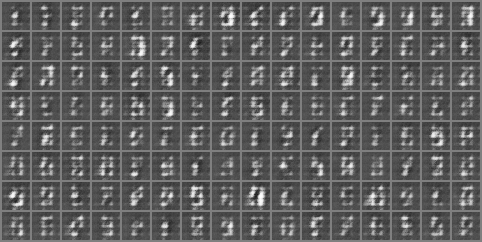

[1/5][200/468][587.4104 s]	Loss_D: -33.8210	Loss_G: 13.4413	Lip(D): 6.9951


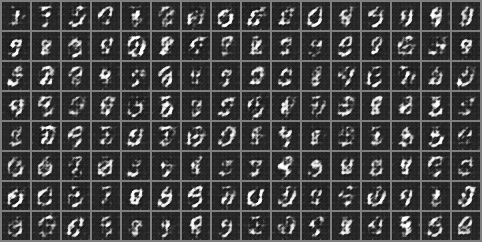

[1/5][300/468][898.7350 s]	Loss_D: -48.8146	Loss_G: 59.2791	Lip(D): 4.1039


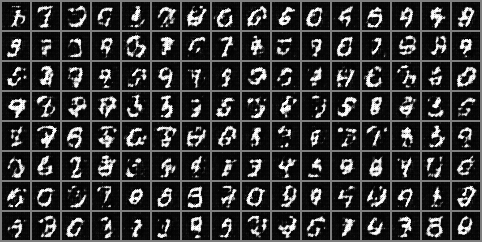

[1/5][400/468][1191.6681 s]	Loss_D: -42.4513	Loss_G: 51.5409	Lip(D): 4.9116


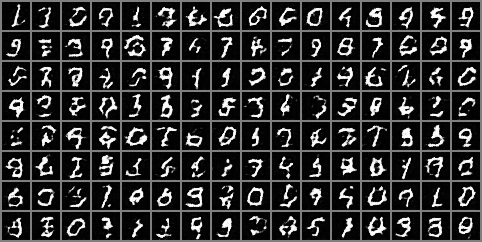

[2/5][0/468][1436.4420 s]	Loss_D: -16.1672	Loss_G: -3.1892	Lip(D): 6.1871


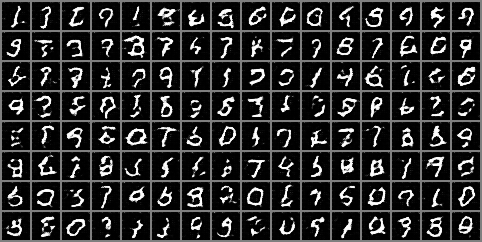

[2/5][100/468][1793.2602 s]	Loss_D: -32.6663	Loss_G: 49.8146	Lip(D): 7.0623


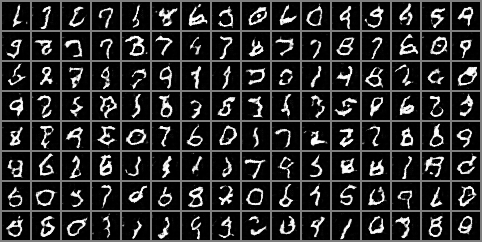

[2/5][200/468][2106.8662 s]	Loss_D: -32.7544	Loss_G: 7.8618	Lip(D): 6.5384


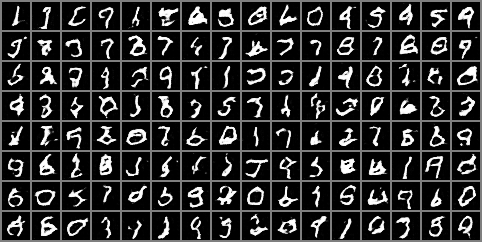

[2/5][300/468][2352.2942 s]	Loss_D: -43.0888	Loss_G: 28.0750	Lip(D): 5.4082


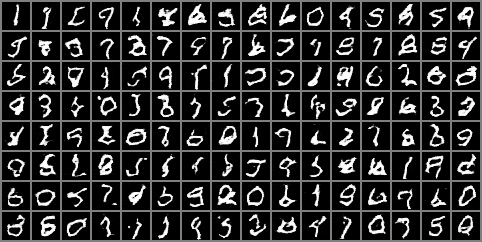

[2/5][400/468][2551.5634 s]	Loss_D: -7.7667	Loss_G: 73.1428	Lip(D): 4.9246


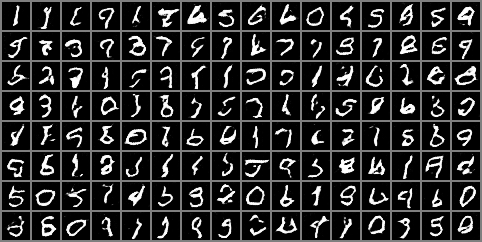

[3/5][0/468][2693.4059 s]	Loss_D: -39.6291	Loss_G: 50.4387	Lip(D): 7.6672


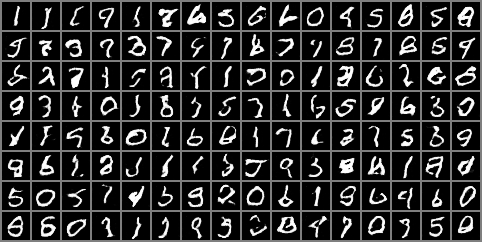

[3/5][100/468][2884.8455 s]	Loss_D: -38.7228	Loss_G: 93.8097	Lip(D): 9.7913


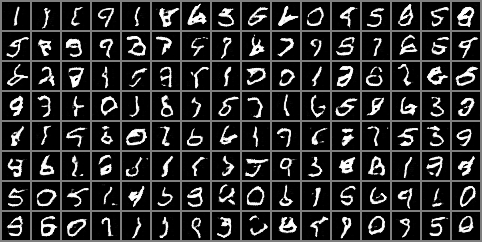

[3/5][200/468][3076.5890 s]	Loss_D: -43.9496	Loss_G: 60.6414	Lip(D): 8.5708


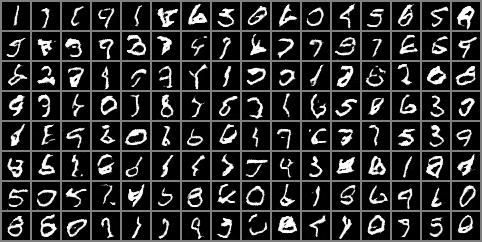

[3/5][300/468][3267.3099 s]	Loss_D: -16.7698	Loss_G: 99.5960	Lip(D): 6.3324


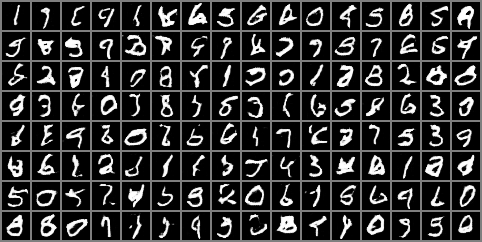

[3/5][400/468][3458.3201 s]	Loss_D: -37.3928	Loss_G: 80.1106	Lip(D): 8.3801


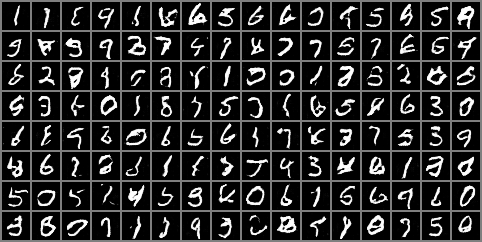

[4/5][0/468][3597.9717 s]	Loss_D: -38.3757	Loss_G: 84.0363	Lip(D): 5.3132


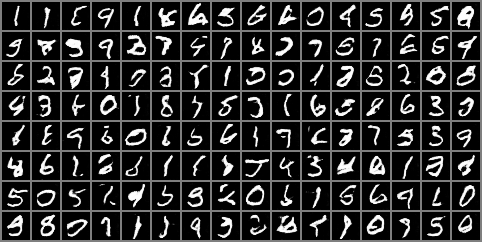

[4/5][100/468][3789.4278 s]	Loss_D: -3.9900	Loss_G: 140.1671	Lip(D): 6.5439


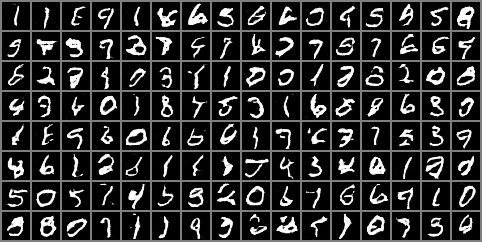

[4/5][200/468][3982.8021 s]	Loss_D: -14.5010	Loss_G: 106.9281	Lip(D): 6.0234


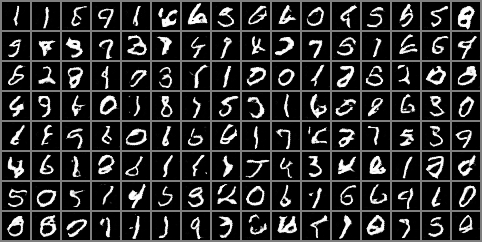

[4/5][300/468][4188.4707 s]	Loss_D: -26.2963	Loss_G: 138.1573	Lip(D): 9.4395


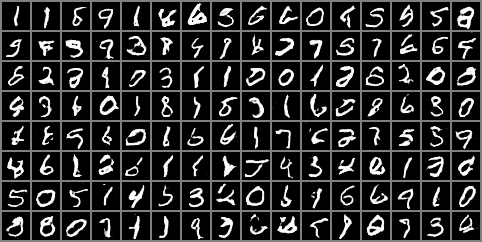

[4/5][400/468][4374.1304 s]	Loss_D: -21.5648	Loss_G: 64.9065	Lip(D): 7.5883


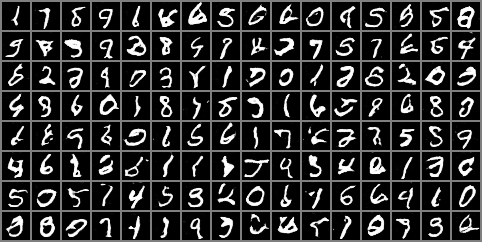

[5/5][0/468][4507.1449 s]	Loss_D: -22.8379	Loss_G: 88.3055	Lip(D): 7.8460


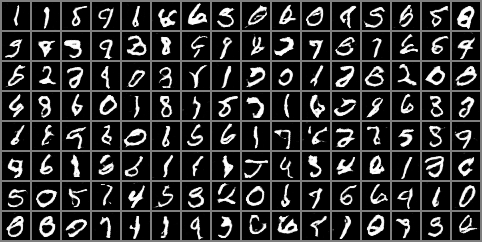

[5/5][100/468][4692.2860 s]	Loss_D: -38.8149	Loss_G: 106.6518	Lip(D): 10.4634


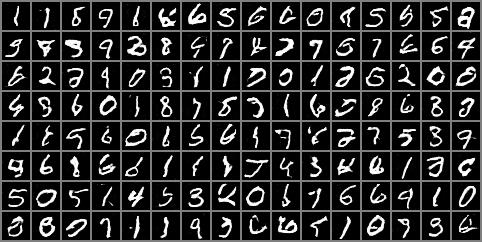

[5/5][200/468][4876.8614 s]	Loss_D: -34.4862	Loss_G: 108.9450	Lip(D): 9.1496


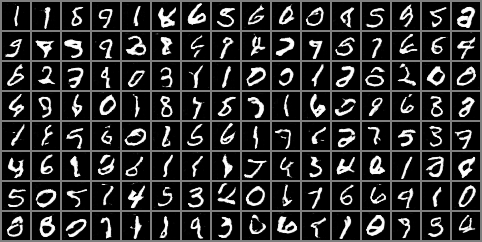

[5/5][300/468][5073.0422 s]	Loss_D: -19.1368	Loss_G: 83.8897	Lip(D): 5.9947


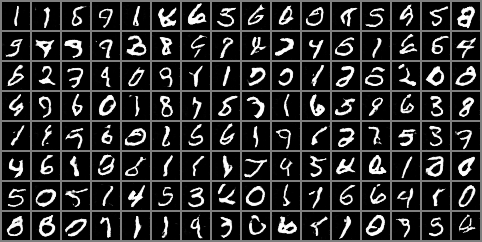

[5/5][400/468][5260.0781 s]	Loss_D: -24.1273	Loss_G: 106.0366	Lip(D): 5.8167


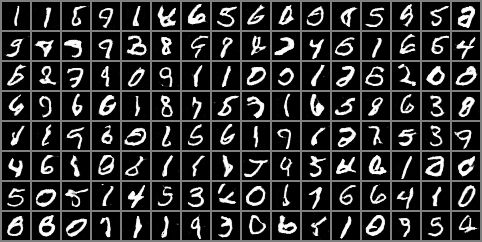

Total learning time =  5384.180011987686


<All keys matched successfully>

In [12]:
torch.manual_seed(1)  # initialize random seed for reproducibility

num_epochs = 5
log_every = 100
gpw = 0.1         # weight of gradient penalty term

G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init);
D.apply(weights_init);

optimD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

zviz = torch.randn(batch_size,nz,1,1).to(device)

t0 = time.time()
for epoch in range(num_epochs):
    # For each batch in the train_loader
    for i, batch in enumerate(train_loader, 0):

        ############################
        # Batchs of real and fake images
        real = batch[0].to(device)
        fake = G(torch.randn(batch_size, nz, 1, 1, device=device))
        faked = fake.detach()

        ############################
        # Update D network (WGAN-GP)
        optimD.zero_grad(set_to_none=True)

        D_real = D(real).mean()
        D_fake = D(faked).mean()

        # D wants to maximize: D_real - D_fake
        # so we minimize the negative + GP
        gp = gradient_penalty(D, real, faked)
        Dloss = -(D_real - D_fake) + gpw * gp

        Dloss.backward()
        optimD.step()

        ############################
        # Update G network (WGAN)
        optimG.zero_grad(set_to_none=True)

        fake = G(torch.randn(batch_size, nz, 1, 1, device=device))
        Gloss = -D(fake).mean()   # G wants to maximize D(fake)

        Gloss.backward()
        optimG.step()

        ############################
        # Display training stats and visualize
        if i % log_every == 0:
            print('[%d/%d][%d/%d][%.4f s]\tLoss_D: %.4f\tLoss_G: %.4f\tLip(D): %.4f'
                  % (epoch+1, num_epochs, i, len(train_loader), time.time()-t0, Dloss.item(), Gloss.item(),meanvariation(D,real,faked)))
            show(G,zviz)

print('Total learning time = ',time.time()-t0)

# Save final generator in a variable for later use
wgan = Generator()
wgan.load_state_dict(G.state_dict())

In [14]:
# Save final generator for later use
torch.save(G.state_dict(), 'wgan.pt')
wgan = Generator()
wgan.load_state_dict(G.state_dict())

<All keys matched successfully>

<br/><br/><br/><br/><br/>

# Part 2 BONUS: Let's play with the Generator

## Interpolation in latent space:

We generate 2 sets of 10 latent variable $z_0$ and $z_1$ and display the generated images by the latent variables:
$$
z_\alpha = (1-\alpha) z_0 + \alpha z_1
$$
for $\alpha$ varying between $0$ and $1$.

Display all the images in a grid of height 10 and width 20 images.

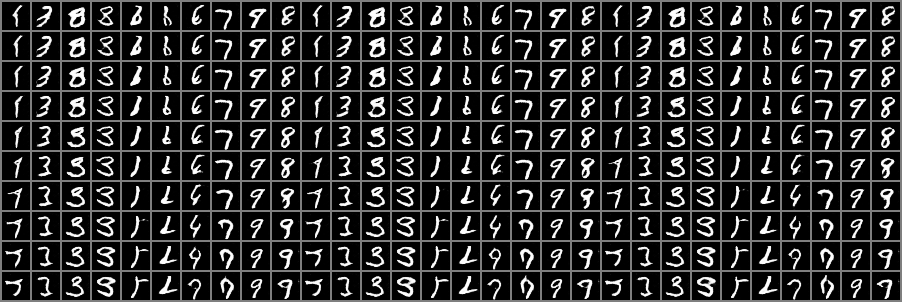

In [ ]:
minib = 10
nk = 30

z0 = torch.randn(minib, nz, 1, 1, device=device)
z1 = torch.randn(minib, nz, 1, 1, device=device)

genimages = torch.zeros((minib*nk,1,28,28))
for k in np.arange(nk):
    alpha = k / (nk - 1)
    z_alpha = (1 - alpha) * z0 + alpha * z1
    with torch.no_grad():
        imgs = G(z_alpha)
    genimages[k*minib:(k+1)*minib] = imgs.cpu()

pil_img = imshow(make_grid(genimages.to('cpu'),nrow=nk))

## Nearest Neighbor in the Dataset

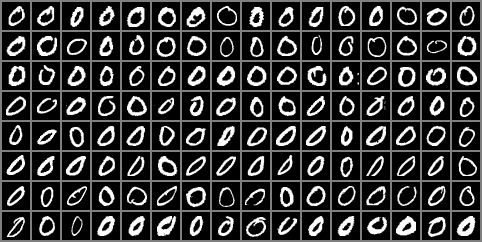

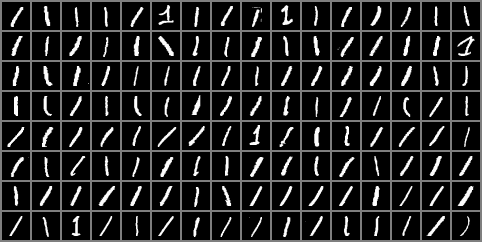

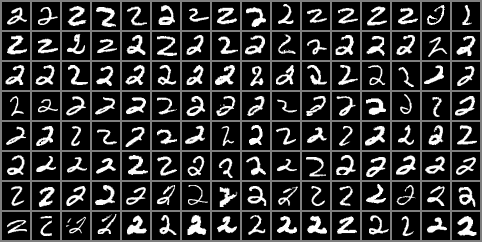

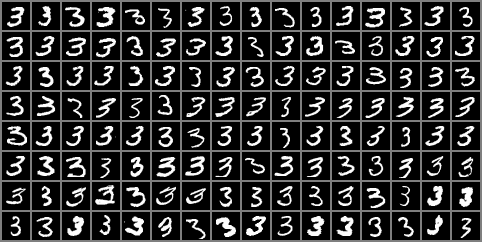

In [16]:
# load all the database
train_loader_all = data.DataLoader(train_set, batch_size=60000, shuffle=False, num_workers=2, drop_last=True)
y,labels = next(iter(train_loader_all))

realzeros = y[labels==0]
realones = y[labels==1]
realtwos = y[labels==2]
realthrees = y[labels==3]
imshow(make_grid(realzeros[0:128,:,:,:].to('cpu'),nrow=16))
imshow(make_grid(realones[0:128,:,:,:].to('cpu'),nrow=16))
imshow(make_grid(realtwos[0:128,:,:,:].to('cpu'),nrow=16))
imshow(make_grid(realthrees[0:128,:,:,:].to('cpu'),nrow=16))

For several samples of the generative model, compute the nearest neighbors in the whole dataset.

Display the samples and their nearest neighbor side by side.

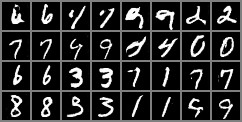

In [17]:
# Generate some fake samples
G.eval()
nsamples = 16

with torch.no_grad():
    z = torch.randn(nsamples, nz, 1, 1, device=device)
    fakes = G(z).cpu()

# Flatten images for distance computation
fakes_flat = fakes.view(nsamples, -1)
real_flat = y.view(y.shape[0], -1)

# Compute nearest neighbors
nearest = []
for i in range(nsamples):
    dists = torch.norm(real_flat - fakes_flat[i], dim=1)
    idx = torch.argmin(dists)
    nearest.append(y[idx])

nearest = torch.stack(nearest)

# Interleave fake and nearest neighbor
combined = torch.zeros(2*nsamples, 1, 28, 28)
combined[0::2] = fakes
combined[1::2] = nearest

imshow(make_grid(combined, nrow=8))

The nearest neighbor analysis shows that generated samples are similar to real digits but not identical, indicating that the model learned the underlying data distribution rather than memorizing the training set.